In [1]:
from src.data_loading import (
    TARGET_COL,
    ID_COL,
    load_data,
)
from src.models import make_lightGBM
from src.training import run_lgbm_cv
from src.evaluation import get_feature_importance, plot_feature_importance, get_error_cases
from sklearn.metrics import roc_auc_score

application_train, application_test = load_data()
X = application_train[[c for c in application_train.columns if c not in [TARGET_COL, ID_COL]]]
y = application_train[TARGET_COL]


In [2]:
results = run_lgbm_cv(X, y)
print(f"mean_auc: {results["mean_auc"]}")
print(f"std_auc: {results["std_auc"]}")
oof_auc = roc_auc_score(y, results["oof_preds"])
print(f"oof_auc: {oof_auc}")

/Users/ryanyao/Quant Projects/Home_Credit/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ryanyao/Quant Projects/Home_Credit/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ryanyao/Quant Projects/Home_Credit/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/ryanyao/Quant Projects/Home_Credit/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


mean_auc: 0.7634015115915003
std_auc: 0.003759999856415856
oof_auc: 0.7633872958255954


/Users/ryanyao/Quant Projects/Home_Credit/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


feature_importance:    index                        feature        fold_1         fold_2  \
0    210          numeric__EXT_SOURCE_2  99402.980523   90008.173563   
1    211          numeric__EXT_SOURCE_3  96069.284750  102734.893425   
2    193  numeric__CREDIT_ANNUITY_RATIO  38607.879084   38748.789064   
3    209          numeric__EXT_SOURCE_1  28920.827944   31282.154120   
4    195            numeric__DAYS_BIRTH  19544.405843   16820.732065   

          fold_3        fold_4         fold_5  mean_importance  std_importance  
0  100397.827281  99345.268012  103063.743039     98443.598483     4951.125158  
1   96536.662275  94715.717744   97300.171372     97471.345913     3088.977531  
2   40534.852571  39368.615245   38000.372877     39052.101768      961.014669  
3   31217.073157  30426.535415   32021.319361     30773.581999     1179.546253  
4   20023.616889  17803.326117   18463.583202     18531.132823     1295.566209  


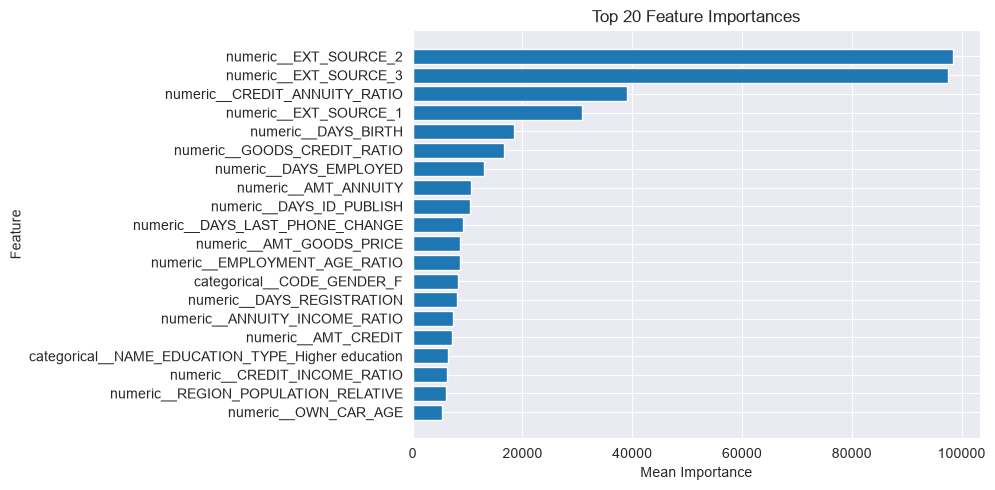

In [3]:
feature_importance = get_feature_importance(results["models"])
print(f"feature_importance: {feature_importance.head(5)}")
fig, axis = plot_feature_importance(feature_importance)

In [6]:
import pandas as pd
from IPython.display import display

false_positives, false_negatives = get_error_cases(X,y,results["oof_preds"])

error_case_summary = pd.DataFrame(
    {
        "group": ["false_positive", "false_negative"],
        "count": [len(false_positives), len(false_negatives)],
        "share_of_all_rows": [len(false_positives) / len(X), len(false_negatives) / len(X)],
        "mean_oof_pred": [false_positives["oof_pred"].mean(), false_negatives["oof_pred"].mean()],
        "median_oof_pred": [false_positives["oof_pred"].median(), false_negatives["oof_pred"].median()],
    }
)

display(error_case_summary)

def raw_column_from_feature(feature):
    if "__" in feature:
        feature = feature.split("__", 1)[1]
    if feature in X.columns:
        return feature
    for col in X.columns:
        if feature.startswith(f"{col}_"):
            return col
    return None

profile_columns = []
for feature in feature_importance["feature"]:
    raw_column = raw_column_from_feature(feature)
    if raw_column is not None and raw_column not in profile_columns:
        profile_columns.append(raw_column)
    if len(profile_columns) == 10:
        break

error_case_columns = ["y_true", "oof_pred", "y_pred"] + profile_columns

print("Highest-risk false positives")
display(false_positives[error_case_columns].head(10))

print("Lowest-risk false negatives")
display(false_negatives[error_case_columns].head(10))

error_profile = pd.DataFrame(
    {
        "overall_median": X[profile_columns].median(numeric_only=True),
        "false_positive_median": false_positives[profile_columns].median(numeric_only=True),
        "false_negative_median": false_negatives[profile_columns].median(numeric_only=True),
    }
)
error_profile["false_positive_minus_overall"] = (
    error_profile["false_positive_median"] - error_profile["overall_median"]
)
error_profile["false_negative_minus_overall"] = (
    error_profile["false_negative_median"] - error_profile["overall_median"]
)

display(error_profile.sort_values("false_negative_minus_overall", key=lambda col: col.abs(), ascending=False))

,group,count,share_of_all_rows,mean_oof_pred,median_oof_pred
0,false_positive,72498,0.235757,0.650504,0.636210
1,false_negative,8878,0.028871,0.331144,0.347174


Highest-risk false positives


,y_true,oof_pred,y_pred,EXT_SOURCE_2,EXT_SOURCE_3,CREDIT_ANNUITY_RATIO,EXT_SOURCE_1,DAYS_BIRTH,GOODS_CREDIT_RATIO,DAYS_EMPLOYED,AMT_ANNUITY,DAYS_ID_PUBLISH,DAYS_LAST_PHONE_CHANGE
13085,0,0.955482,1,0.001555,0.294083,12.656731,0.073574,-9924,1.000000,-269.0,38043.0,-334,-585.0
110671,0,0.953180,1,0.006472,0.034626,25.809262,NaN,-10346,0.716332,-184.0,24583.5,-1085,-359.0
117624,0,0.947718,1,0.132674,0.307737,12.593603,NaN,-18269,0.791139,-831.0,25744.5,-1807,-938.0
108028,0,0.947714,1,0.006189,0.067340,12.600410,NaN,-12572,1.000000,-5501.0,28570.5,-5241,-588.0
222608,0,0.947339,1,0.009793,0.408359,14.721227,NaN,-13066,0.759420,-488.0,31396.5,-2218,-345.0
66660,0,0.943433,1,0.060446,0.025810,14.734251,NaN,-11062,0.759417,-236.0,40216.5,-776,0.0
223512,0,0.942865,1,0.086239,0.121408,21.452356,NaN,-14613,0.825627,-199.0,25407.0,-1735,-1808.0
250227,0,0.942255,1,0.000674,0.054584,20.560177,0.514440,-13904,0.825627,-562.0,26509.5,-882,-1587.0
212645,0,0.941603,1,0.017525,0.041759,12.656893,0.174172,-11027,1.000000,-2164.0,42664.5,-3536,-494.0
174156,0,0.941124,1,0.017040,0.049263,20.437359,NaN,-10117,1.000000,-2863.0,22018.5,-2759,-906.0


Lowest-risk false negatives


,y_true,oof_pred,y_pred,EXT_SOURCE_2,EXT_SOURCE_3,CREDIT_ANNUITY_RATIO,EXT_SOURCE_1,DAYS_BIRTH,GOODS_CREDIT_RATIO,DAYS_EMPLOYED,AMT_ANNUITY,DAYS_ID_PUBLISH,DAYS_LAST_PHONE_CHANGE
270264,1,0.011967,0,0.744295,NaN,10.212920,NaN,-24185,0.883392,-10690.0,24939.0,-4577,-1959.0
149576,1,0.016677,0,0.521937,0.768808,30.813476,0.879373,-18550,1.000000,-641.0,21906.0,-2100,0.0
219787,1,0.016797,0,0.629838,0.641368,25.145545,0.903609,-21489,0.919863,-858.0,45913.5,-4699,-1236.0
96085,1,0.016942,0,0.771501,NaN,31.847733,0.902648,-23575,0.895930,-2966.0,33750.0,-4656,-1370.0
171712,1,0.017467,0,0.700609,0.750375,18.771240,0.909331,-23131,0.945108,-6136.0,60115.5,-4891,0.0
196106,1,0.021832,0,0.687924,0.171468,26.946050,0.812237,-13042,0.893815,-2629.0,93420.0,-4231,-1.0
172682,1,0.027471,0,0.552557,0.852828,20.000000,NaN,-15467,1.000000,-2665.0,22500.0,-3878,-376.0
295445,1,0.029032,0,0.782793,0.517297,20.000000,0.294416,-10864,1.000000,-3103.0,9000.0,-3407,-649.0
63195,1,0.031809,0,0.774895,0.827703,16.345211,NaN,-13616,1.000000,-3467.0,41296.5,-4766,-2463.0
9297,1,0.033834,0,0.694445,0.565608,17.421603,0.627767,-14964,1.000000,-5560.0,12915.0,-5018,-1407.0


,overall_median,false_positive_median,false_negative_median,false_positive_minus_overall,false_negative_minus_overall
DAYS_BIRTH,-15750.000000,-13829.000000,-16042.000000,1921.000000,-292.000000
DAYS_ID_PUBLISH,-3254.000000,-2687.000000,-3335.000000,567.000000,-81.000000
DAYS_EMPLOYED,-1648.000000,-1163.000000,-1705.000000,485.000000,-57.000000
AMT_ANNUITY,24903.000000,24903.000000,24939.000000,0.000000,36.000000
DAYS_LAST_PHONE_CHANGE,-757.000000,-562.000000,-789.500000,195.000000,-32.500000
CREDIT_ANNUITY_RATIO,20.000000,20.000000,20.610435,0.000000,0.610435
EXT_SOURCE_3,0.535276,0.339288,0.544235,-0.195989,0.008958
EXT_SOURCE_2,0.565961,0.404125,0.574461,-0.161836,0.008499
EXT_SOURCE_1,0.505998,0.332051,0.507150,-0.173947,0.001152
GOODS_CREDIT_RATIO,0.893815,0.863261,0.893815,-0.030554,0.000000
